# Siamese Latent Alignment — Bio-Inspired Contrastive Memory

**Inspiración biológica:** El hipocampo almacena representaciones invariantes del mismo estímulo
bajo diferentes condiciones. Cuando vemos la misma escena bajo lluvia y sol, formamos la
misma memoria central — las variaciones sensoriales se eliminan en la consolidación.

**Problema detectado en Orthogonal Training:** El VAE autocodifica el ruido en lugar de
eliminarlo. La reconstrucción de features ruidosos simplemente reproduce features ruidosos,
sin acercarlos al espacio limpio que el clasificador experto entiende.

**Solución Siamese:** Durante Phase 2, el modelo ve simultáneamente la imagen limpia y la
ruidosa del mismo estímulo. La loss fuerza al latente ruidoso a alinearse con el latente limpio:

$$\mathcal{L}_{align} = \text{MSE}(\mu_{noisy}, \mu_{clean}) + \lambda_{cos}(1 - \cos(\mu_{noisy}, \mu_{clean}))$$

## Protocolo
| Modelo | Fase 1 (clean expert) | Fase 2 (siamese memory) | Entrenado Fase 2 |
|---|---|---|---|
| **ResNet Baseline** | — | 50% noisy training | fc |
| **DeMemte Siamese** | Todo (clean) → Experto | VAE ve (noisy, clean) simultáneamente | conv_vae, gate, memory_scale |

## Loss Siamese (Phase 2)
```
L = task_loss + vae_w * (recon_to_clean + KLD) + align_w * MSE(μ_n, μ_c) + cos_w * (1 - cos(μ_n, μ_c)) + sparsity
```
- **recon_to_clean**: El decoder debe reconstruir features LIMPIOS a partir de la entrada ruidosa
- **align**: El latente de la imagen ruidosa debe converger al latente de la imagen limpia
- **cosine**: Alineación direccional del latente (complementa la magnitud del MSE)

In [1]:
import os
import copy
from copy import deepcopy
import random
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Componentes base

In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, hard_threshold=0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))
        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x):
        if x.ndim != 2 or x.shape[1] != self.in_features:
            raise ValueError(f'x debe ser (B, {self.in_features})')
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft
        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    def sparsity_loss(self):
        return torch.sigmoid(self.logits / self.temperature).mean()


class ConvVAE(nn.Module):
    """VAE convolucional sobre feature maps espaciales [B, C, H, W]."""
    def __init__(self, channels=512, latent_dim=128, spatial=7):
        super().__init__()
        self.channels = channels
        self.spatial = spatial
        self.enc = nn.Sequential(
            nn.Conv2d(channels, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        flat_dim = 128 * spatial * spatial
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, flat_dim)
        self.dec = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, channels, 3, padding=1),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, self.spatial, self.spatial)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


class DeMemte_SiameseMemory(nn.Module):
    """
    DeMemte con Memoria Siamese para Alineación Latente.
    
    Innovación clave: forward() acepta `clean_x` opcional.
    Cuando se provee, el VAE codifica AMBAS versiones (ruidosa y limpia)
    del mismo estímulo, retornando los latentes de ambas para calcular
    la loss de alineación contrastiva.
    
    Gating: Robust Sigmoid paramétrica (igual que orthogonal training).
    Reconstrucción: El decoder siempre reconstruye hacia features LIMPIOS.
    """
    def __init__(self, spatial_backbone, conv_vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = spatial_backbone
        self.conv_vae = conv_vae
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)
        # Robust Gating params
        self.gate_tau = nn.Parameter(torch.tensor([0.0]))
        self.gate_alpha = nn.Parameter(torch.tensor([2.0]))

    def _extract_backbone(self, x):
        """Extrae features espaciales del backbone congelado."""
        with torch.no_grad():
            return self.backbone(x)

    def _robust_gate(self, spatial_feats, spatial_rec):
        """Compuerta robusta normalizada por batch."""
        recon_diff = ((spatial_feats - spatial_rec) ** 2).mean(dim=1, keepdim=True)
        center = recon_diff.mean(dim=(0, 2, 3), keepdim=True)
        scale = recon_diff.std(dim=(0, 2, 3), keepdim=True) + 1e-6
        recon_norm = (recon_diff - center) / scale
        alpha = F.softplus(self.gate_alpha)
        return torch.sigmoid(alpha * (self.gate_tau - recon_norm))

    def forward(self, x, clean_x=None):
        """
        Forward pass Siamese.
        
        Args:
            x: imagen de entrada (puede ser limpia o ruidosa)
            clean_x: imagen limpia del mismo estímulo (solo en Phase 2 training)
        
        Returns:
            logits, x_rec, mu, logvar, features
            + (clean_mu, clean_logvar, clean_spatial) si clean_x is not None
        """
        spatial_feats = self._extract_backbone(x)
        spatial_rec, mu, logvar = self.conv_vae(spatial_feats)
        signal = self._robust_gate(spatial_feats, spatial_rec)
        enhanced_spatial = spatial_feats + self.memory_scale * signal * spatial_rec

        features = self.feat_norm(self.pool(spatial_feats).flatten(1))
        enhanced = self.feat_norm(self.pool(enhanced_spatial).flatten(1))
        logits = self.classifier(enhanced)
        x_rec = self.pool(spatial_rec).flatten(1)

        if clean_x is not None:
            # Rama Siamese: codificar la versión limpia
            clean_spatial = self._extract_backbone(clean_x)
            _, clean_mu, clean_logvar = self.conv_vae(clean_spatial)
            clean_feats_pooled = self.pool(clean_spatial).flatten(1)
            return logits, x_rec, mu, logvar, features, clean_mu, clean_logvar, clean_feats_pooled

        return logits, x_rec, mu, logvar, features

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self


def make_spatial_backbone():
    base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base.children())[:-2])
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()
    return backbone


EMBEDDING_DIM = 512
NUM_CLASSES = 102
LATENT_DIM = 128
print('Componentes definidos: LearnedSparseLinear, ConvVAE, DeMemte_SiameseMemory.')

Componentes definidos: LearnedSparseLinear, ConvVAE, DeMemte_SiameseMemory.


## Datos

In [3]:
BATCH_SIZE = 64
NOISE_STD = 0.5
EPOCHS_P1 = 30
EPOCHS_P2 = 30
PATIENCE = 6
MIN_DELTA = 0.10
DATA_DIR = '../../data'

# Pesos de la loss Siamese
ALIGN_WEIGHT = 1.0    # MSE entre latentes noisy/clean
COSINE_WEIGHT = 0.5   # Distancia coseno entre latentes
VAE_WEIGHT = 0.1      # Reconstrucción + KLD
SPARSITY_WEIGHT = 0.002

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

trainset = torchvision.datasets.Flowers102(root=DATA_DIR, split='train', download=True, transform=transform_train)
valset   = torchvision.datasets.Flowers102(root=DATA_DIR, split='val',   download=True, transform=transform_test)
testset  = torchvision.datasets.Flowers102(root=DATA_DIR, split='test',  download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valloader   = DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(trainset)} | Val: {len(valset)} | Test: {len(testset)}')
print(f'Siamese loss weights: align={ALIGN_WEIGHT}, cosine={COSINE_WEIGHT}, vae={VAE_WEIGHT}')


def add_noise(x, std=NOISE_STD):
    return x + torch.randn_like(x) * std

Train: 1020 | Val: 1020 | Test: 6149
Siamese loss weights: align=1.0, cosine=0.5, vae=0.1


## Funciones de evaluación y pérdida

In [4]:
@torch.no_grad()
def evaluate(model, loader, noise_std=0.0, is_dememte=True):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if noise_std > 0:
            x = add_noise(x, std=noise_std)
        if is_dememte:
            logits = model(x)[0]
        else:
            logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / total


def robust_score(clean_acc, noisy_acc):
    """Métrica objetivo: prioriza robustez sin ignorar clean."""
    return 0.4 * clean_acc + 0.6 * noisy_acc


def compute_loss_phase1(logits, labels, x_rec, features, mu, logvar, model):
    """Loss estándar para Phase 1 (solo clean, sin alignment)."""
    task = F.cross_entropy(logits, labels, label_smoothing=0.05)
    recon = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    s_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    return task + VAE_WEIGHT * (recon + kld) + SPARSITY_WEIGHT * s_loss


def compute_loss_siamese(logits, labels, x_rec, features, mu, logvar,
                          clean_mu, clean_logvar, clean_features, model):
    """
    Loss Siamese para Phase 2.
    
    Innovación: El VAE procesa la misma imagen en su versión ruidosa y limpia.
    Los términos de alineación fuerzan al latente ruidoso a converger al limpio:
    
    1. task_loss:   CrossEntropy de clasificación (señal de tarea)
    2. recon_clean: MSE(decoder(z_noisy), features_clean) — reconstruir lo limpio
    3. align_mse:   MSE(mu_noisy, mu_clean) — alineación en magnitud
    4. cosine_dist: 1 - cos(mu_noisy, mu_clean) — alineación direccional
    5. kld:         Regularización del espacio latente
    6. sparsity:    Regularización del clasificador sparse
    """
    task = F.cross_entropy(logits, labels, label_smoothing=0.05)
    
    # Reconstrucción HACIA features limpios (no autorreconstrucción ruidosa)
    recon_clean = F.mse_loss(x_rec, clean_features, reduction='sum') / features.size(0)
    
    # Alineación latente: mu_noisy → mu_clean (detach clean para no backprop a la rama limpia)
    align_mse = F.mse_loss(mu, clean_mu.detach())
    cosine_dist = 1.0 - F.cosine_similarity(mu, clean_mu.detach(), dim=1).mean()
    
    # KLD estándar
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    
    # Sparsity del clasificador
    s_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    
    total = (task
             + VAE_WEIGHT * (recon_clean + kld)
             + ALIGN_WEIGHT * align_mse
             + COSINE_WEIGHT * cosine_dist
             + SPARSITY_WEIGHT * s_loss)
    
    return total, {
        'task': task.item(),
        'recon_clean': recon_clean.item(),
        'align_mse': align_mse.item(),
        'cosine_dist': cosine_dist.item(),
        'kld': kld.item(),
    }


print('Loss functions definidas: compute_loss_phase1, compute_loss_siamese.')

Loss functions definidas: compute_loss_phase1, compute_loss_siamese.


---
## 1. ResNet Baseline (50% noisy training)

Backbone congelado (ImageNet) + clasificador lineal con:
- **AdamW** (weight_decay=1e-4) + **label_smoothing=0.05**
- **ReduceLROnPlateau** + **early stopping** (patience=6) sobre `robust_score` en `valloader`
- Ruido gaussiano (std=0.5) al 50% de los batches

In [5]:
def get_resnet_baseline(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


resnet = get_resnet_baseline()
opt_resnet = optim.AdamW(resnet.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    opt_resnet, mode='max', factor=0.5, patience=2, threshold=0.05, min_lr=1e-6
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

history_resnet = {'train_acc': [], 'clean_acc': [], 'noisy_acc': [], 'score': [], 'lr': []}
best_resnet_state = None
best_resnet_score = -float('inf')
best_resnet_epoch = 0
no_improve_resnet = 0

print('=== ResNet Baseline (50% Noisy Training, Early Stopping) ===')
for epoch in range(EPOCHS_P1):
    resnet.train()
    correct, total = 0, 0
    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        if random.random() < 0.5:
            x = add_noise(x)
        opt_resnet.zero_grad()
        logits = resnet(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(resnet.parameters(), max_norm=1.0)
        opt_resnet.step()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(resnet, valloader, noise_std=0.0, is_dememte=False)
    noisy_acc = evaluate(resnet, valloader, noise_std=NOISE_STD, is_dememte=False)
    score = robust_score(clean_acc, noisy_acc)
    scheduler_resnet.step(score)
    current_lr = opt_resnet.param_groups[0]['lr']

    history_resnet['train_acc'].append(train_acc)
    history_resnet['clean_acc'].append(clean_acc)
    history_resnet['noisy_acc'].append(noisy_acc)
    history_resnet['score'].append(score)
    history_resnet['lr'].append(current_lr)

    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | '
          f'ValClean: {clean_acc:.1f}% | ValNoisy: {noisy_acc:.1f}% | '
          f'Score: {score:.2f} | LR: {current_lr:.2e}')

    if score > best_resnet_score + MIN_DELTA:
        best_resnet_score = score
        best_resnet_epoch = epoch + 1
        best_resnet_state = deepcopy(resnet.state_dict())
        no_improve_resnet = 0
    else:
        no_improve_resnet += 1

    if no_improve_resnet >= PATIENCE:
        print(f'  Early stopping en epoch {epoch+1}. Mejor epoch: {best_resnet_epoch} | Score: {best_resnet_score:.2f}')
        break

if best_resnet_state is not None:
    resnet.load_state_dict(best_resnet_state)

resnet_test_clean = evaluate(resnet, testloader, noise_std=0.0, is_dememte=False)
resnet_test_noisy = evaluate(resnet, testloader, noise_std=NOISE_STD, is_dememte=False)
print(f'\nResNet (mejor epoch {best_resnet_epoch}) -> Test Clean: {resnet_test_clean:.2f}% | Test Noisy: {resnet_test_noisy:.2f}%')

=== ResNet Baseline (50% Noisy Training, Early Stopping) ===
  Epoch 1/30 | Train: 3.1% | ValClean: 4.6% | ValNoisy: 7.5% | Score: 6.37 | LR: 1.00e-03
  Epoch 2/30 | Train: 20.0% | ValClean: 22.9% | ValNoisy: 19.3% | Score: 20.76 | LR: 1.00e-03
  Epoch 3/30 | Train: 48.2% | ValClean: 20.0% | ValNoisy: 34.3% | Score: 28.59 | LR: 1.00e-03
  Epoch 4/30 | Train: 69.5% | ValClean: 41.0% | ValNoisy: 36.7% | Score: 38.39 | LR: 1.00e-03
  Epoch 5/30 | Train: 73.0% | ValClean: 26.3% | ValNoisy: 47.9% | Score: 39.27 | LR: 1.00e-03
  Epoch 6/30 | Train: 81.3% | ValClean: 25.4% | ValNoisy: 50.9% | Score: 40.69 | LR: 1.00e-03
  Epoch 7/30 | Train: 86.5% | ValClean: 40.9% | ValNoisy: 51.2% | Score: 47.06 | LR: 1.00e-03
  Epoch 8/30 | Train: 90.2% | ValClean: 48.5% | ValNoisy: 50.8% | Score: 49.88 | LR: 1.00e-03
  Epoch 9/30 | Train: 89.8% | ValClean: 44.0% | ValNoisy: 52.0% | Score: 48.78 | LR: 1.00e-03
  Epoch 10/30 | Train: 91.4% | ValClean: 29.0% | ValNoisy: 57.6% | Score: 46.20 | LR: 1.00e-03
  

---
## 2. DeMemte Siamese — Fase 1: Experto Clean

Entrenamos **todos** los componentes con imágenes limpias (sin rama Siamese).
El objetivo es maximizar Clean Accuracy — este es nuestro techo.

- Forward estándar (sin `clean_x`) — idéntico al orthogonal training
- Loss: `compute_loss_phase1` (task + VAE + sparsity)
- Early stopping sobre `robust_score` en `valloader`

In [6]:
model = DeMemte_SiameseMemory(
    make_spatial_backbone(),
    ConvVAE(channels=512, latent_dim=LATENT_DIM, spatial=7),
    EMBEDDING_DIM, NUM_CLASSES
).to(device)

opt_p1 = optim.AdamW([
    {'params': model.conv_vae.parameters(), 'lr': 3e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-2},
    {'params': [model.gate_tau, model.gate_alpha, model.memory_scale, *model.feat_norm.parameters()], 'lr': 1e-2},
], weight_decay=1e-4)

scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    opt_p1, mode='max', factor=0.5, patience=2, threshold=0.05, min_lr=1e-6
)

history_p1 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': [], 'score': [], 'lr': []}
best_p1_state = None
best_p1_score = -float('inf')
best_p1_epoch = 0
no_improve_p1 = 0

print('=== FASE 1: Entrenamiento Clean (Experto) ===')
for epoch in range(EPOCHS_P1):
    model.train()
    correct, total = 0, 0

    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        opt_p1.zero_grad()
        logits, x_rec, mu, logvar, features = model(x)  # sin clean_x
        loss = compute_loss_phase1(logits, y, x_rec, features, mu, logvar, model)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt_p1.step()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, valloader, noise_std=0.0)
    noisy_acc = evaluate(model, valloader, noise_std=NOISE_STD)
    score = robust_score(clean_acc, noisy_acc)
    scheduler_p1.step(score)
    current_lr = opt_p1.param_groups[0]['lr']

    history_p1['train_acc'].append(train_acc)
    history_p1['clean_acc'].append(clean_acc)
    history_p1['noisy_acc'].append(noisy_acc)
    history_p1['score'].append(score)
    history_p1['lr'].append(current_lr)

    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | '
          f'ValClean: {clean_acc:.1f}% | ValNoisy: {noisy_acc:.1f}% | '
          f'Score: {score:.2f} | LR: {current_lr:.2e}')

    if score > best_p1_score + MIN_DELTA:
        best_p1_score = score
        best_p1_epoch = epoch + 1
        best_p1_state = deepcopy(model.state_dict())
        no_improve_p1 = 0
    else:
        no_improve_p1 += 1

    if no_improve_p1 >= PATIENCE:
        print(f'  Early stopping en epoch {epoch+1}. Mejor epoch: {best_p1_epoch} | Score: {best_p1_score:.2f}')
        break

if best_p1_state is not None:
    model.load_state_dict(best_p1_state)

phase1_test_clean = evaluate(model, testloader, noise_std=0.0)
phase1_test_noisy = evaluate(model, testloader, noise_std=NOISE_STD)
print(f'\n>>> Fase 1 (mejor epoch {best_p1_epoch}) -> Test Clean: {phase1_test_clean:.2f}% | Test Noisy: {phase1_test_noisy:.2f}%')
print(f'>>> Este {phase1_test_clean:.2f}% es nuestro TECHO. La Fase 2 no debe perderlo.')

=== FASE 1: Entrenamiento Clean (Experto) ===
  Epoch 1/30 | Train: 27.2% | ValClean: 60.4% | ValNoisy: 31.2% | Score: 42.86 | LR: 3.00e-05
  Epoch 2/30 | Train: 81.7% | ValClean: 73.9% | ValNoisy: 39.3% | Score: 53.16 | LR: 3.00e-05
  Epoch 3/30 | Train: 93.2% | ValClean: 76.8% | ValNoisy: 39.9% | Score: 54.65 | LR: 3.00e-05
  Epoch 4/30 | Train: 96.8% | ValClean: 78.8% | ValNoisy: 40.6% | Score: 55.88 | LR: 3.00e-05
  Epoch 5/30 | Train: 97.1% | ValClean: 80.6% | ValNoisy: 40.0% | Score: 56.24 | LR: 3.00e-05
  Epoch 6/30 | Train: 97.7% | ValClean: 80.1% | ValNoisy: 40.3% | Score: 56.22 | LR: 3.00e-05
  Epoch 7/30 | Train: 98.4% | ValClean: 80.6% | ValNoisy: 41.2% | Score: 56.94 | LR: 1.50e-05
  Epoch 8/30 | Train: 99.4% | ValClean: 80.8% | ValNoisy: 40.9% | Score: 56.84 | LR: 1.50e-05
  Epoch 9/30 | Train: 99.5% | ValClean: 81.8% | ValNoisy: 41.0% | Score: 57.29 | LR: 1.50e-05
  Epoch 10/30 | Train: 99.2% | ValClean: 80.4% | ValNoisy: 42.7% | Score: 57.80 | LR: 7.50e-06
  Epoch 11/30

In [7]:
# Snapshot del clasificador para verificación posterior
classifier_snapshot = {k: v.clone() for k, v in model.classifier.state_dict().items()}
feat_norm_snapshot  = {k: v.clone() for k, v in model.feat_norm.state_dict().items()}
print(f'Snapshot del clasificador guardado ({len(classifier_snapshot)} tensores).')
print(f'Snapshot de feat_norm guardado ({len(feat_norm_snapshot)} tensores).')
print(f'\nPhase 1 best score: {best_p1_score:.2f} (epoch {best_p1_epoch})')

Snapshot del clasificador guardado (3 tensores).
Snapshot de feat_norm guardado (2 tensores).

Phase 1 best score: 57.80 (epoch 10)


---
## 3. DeMemte Siamese — Fase 2: Memoria con Alineación Latente

**Congelamos** clasificador y feat_norm. Solo entrenamos:
- `conv_vae` (encoder + decoder)
- `gate_tau`, `gate_alpha`, `memory_scale`

**Innovación Siamese:** Cada batch procesa el par `(x_noisy, x_clean)` del mismo estímulo.
El VAE codifica ambos, y la loss incluye:
1. **Recon → clean**: `MSE(decoder(z_noisy), features_clean)` — reconstrucción denoising
2. **Align MSE**: `MSE(μ_noisy, μ_clean.detach())` — alineación latente
3. **Cosine**: `1 - cos(μ_noisy, μ_clean.detach())` — alineación direccional
4. **KLD**: Regularización del espacio latente

El `.detach()` en `μ_clean` evita que el gradiente modifique la codificación de la imagen
limpia — solo el latente ruidoso se mueve hacia el limpio.

In [8]:
# === CONGELAR clasificador y feat_norm ===
for p in model.classifier.parameters():
    p.requires_grad = False
for p in model.feat_norm.parameters():
    p.requires_grad = False

trainable = {n: p.numel() for n, p in model.named_parameters() if p.requires_grad}
frozen    = {n: p.numel() for n, p in model.named_parameters() if not p.requires_grad}

print('--- Parámetros ENTRENABLES (Fase 2) ---')
for n, count in trainable.items():
    print(f'  {n}: {count:,}')
print(f'  TOTAL entrenable: {sum(trainable.values()):,}')
print(f'\n--- Parámetros CONGELADOS ---')
print(f'  TOTAL congelado: {sum(frozen.values()):,}  ({len(frozen)} tensores)')

--- Parámetros ENTRENABLES (Fase 2) ---
  memory_scale: 1
  gate_tau: 1
  gate_alpha: 1
  conv_vae.enc.0.weight: 1,179,648
  conv_vae.enc.0.bias: 256
  conv_vae.enc.1.weight: 256
  conv_vae.enc.1.bias: 256
  conv_vae.enc.3.weight: 294,912
  conv_vae.enc.3.bias: 128
  conv_vae.enc.4.weight: 128
  conv_vae.enc.4.bias: 128
  conv_vae.fc_mu.weight: 802,816
  conv_vae.fc_mu.bias: 128
  conv_vae.fc_logvar.weight: 802,816
  conv_vae.fc_logvar.bias: 128
  conv_vae.fc_dec.weight: 802,816
  conv_vae.fc_dec.bias: 6,272
  conv_vae.dec.0.weight: 294,912
  conv_vae.dec.0.bias: 256
  conv_vae.dec.1.weight: 256
  conv_vae.dec.1.bias: 256
  conv_vae.dec.3.weight: 1,179,648
  conv_vae.dec.3.bias: 512
  TOTAL entrenable: 5,366,531

--- Parámetros CONGELADOS ---
  TOTAL congelado: 11,282,086  (65 tensores)


In [9]:
opt_p2 = optim.AdamW([
    {'params': model.conv_vae.parameters(), 'lr': 3e-5},
    {'params': [model.gate_tau, model.gate_alpha, model.memory_scale], 'lr': 1e-3},
], weight_decay=1e-4)

scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    opt_p2, mode='max', factor=0.5, patience=2, threshold=0.05, min_lr=1e-6
)

history_p2 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': [], 'score': [], 'lr': [],
              'align_mse': [], 'cosine_dist': [], 'recon_clean': []}
best_p2_state = None
best_p2_score = -float('inf')
best_p2_epoch = 0
no_improve_p2 = 0

print('=== FASE 2: Memoria Siamese (clasificador CONGELADO) ===')
print(f'    Align weight: {ALIGN_WEIGHT} | Cosine weight: {COSINE_WEIGHT} | VAE weight: {VAE_WEIGHT}')
print()

for epoch in range(EPOCHS_P2):
    model.train()
    correct, total = 0, 0
    epoch_losses = {'task': 0, 'recon_clean': 0, 'align_mse': 0, 'cosine_dist': 0, 'kld': 0}
    n_batches = 0

    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.conv_vae.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        x_noisy = add_noise(x)

        opt_p2.zero_grad()
        # Forward Siamese: noisy + clean del mismo estímulo
        logits, x_rec, mu, logvar, features, clean_mu, clean_logvar, clean_features = model(x_noisy, clean_x=x)

        loss, loss_dict = compute_loss_siamese(
            logits, y, x_rec, features, mu, logvar,
            clean_mu, clean_logvar, clean_features, model
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt_p2.step()

        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
        for k in epoch_losses:
            epoch_losses[k] += loss_dict.get(k, 0)
        n_batches += 1

    # Promediar losses del epoch
    for k in epoch_losses:
        epoch_losses[k] /= max(n_batches, 1)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, valloader, noise_std=0.0)
    noisy_acc = evaluate(model, valloader, noise_std=NOISE_STD)
    score = robust_score(clean_acc, noisy_acc)
    scheduler_p2.step(score)
    current_lr = opt_p2.param_groups[0]['lr']

    history_p2['train_acc'].append(train_acc)
    history_p2['clean_acc'].append(clean_acc)
    history_p2['noisy_acc'].append(noisy_acc)
    history_p2['score'].append(score)
    history_p2['lr'].append(current_lr)
    history_p2['align_mse'].append(epoch_losses['align_mse'])
    history_p2['cosine_dist'].append(epoch_losses['cosine_dist'])
    history_p2['recon_clean'].append(epoch_losses['recon_clean'])

    print(f'  Epoch {epoch+1}/{EPOCHS_P2} | Train(noisy): {train_acc:.1f}% | '
          f'ValClean: {clean_acc:.1f}% | ValNoisy: {noisy_acc:.1f}% | '
          f'Score: {score:.2f} | LR: {current_lr:.2e}')
    print(f'    Losses → task: {epoch_losses["task"]:.4f} | recon→clean: {epoch_losses["recon_clean"]:.4f} | '
          f'align_mse: {epoch_losses["align_mse"]:.4f} | cosine: {epoch_losses["cosine_dist"]:.4f} | '
          f'kld: {epoch_losses["kld"]:.4f}')

    if score > best_p2_score + MIN_DELTA:
        best_p2_score = score
        best_p2_epoch = epoch + 1
        best_p2_state = deepcopy(model.state_dict())
        no_improve_p2 = 0
    else:
        no_improve_p2 += 1

    if no_improve_p2 >= PATIENCE:
        print(f'  Early stopping en epoch {epoch+1}. Mejor epoch: {best_p2_epoch} | Score: {best_p2_score:.2f}')
        break

if best_p2_state is not None:
    model.load_state_dict(best_p2_state)

phase2_test_clean = evaluate(model, testloader, noise_std=0.0)
phase2_test_noisy = evaluate(model, testloader, noise_std=NOISE_STD)
print(f'\n>>> Fase 2 Siamese (mejor epoch {best_p2_epoch}) -> Test Clean: {phase2_test_clean:.2f}% | Test Noisy: {phase2_test_noisy:.2f}%')

=== FASE 2: Memoria Siamese (clasificador CONGELADO) ===
    Align weight: 1.0 | Cosine weight: 0.5 | VAE weight: 0.1

  Epoch 1/30 | Train(noisy): 58.5% | ValClean: 80.5% | ValNoisy: 41.8% | Score: 57.25 | LR: 3.00e-05
    Losses → task: 2.2186 | recon→clean: 484.4639 | align_mse: 0.0026 | cosine: 0.1353 | kld: 0.9512
  Epoch 2/30 | Train(noisy): 55.8% | ValClean: 80.4% | ValNoisy: 39.7% | Score: 55.98 | LR: 3.00e-05
    Losses → task: 2.2271 | recon→clean: 335.3870 | align_mse: 0.0024 | cosine: 0.0956 | kld: 1.0397
  Epoch 3/30 | Train(noisy): 55.3% | ValClean: 80.1% | ValNoisy: 40.6% | Score: 56.39 | LR: 3.00e-05
    Losses → task: 2.2232 | recon→clean: 267.2297 | align_mse: 0.0023 | cosine: 0.0923 | kld: 1.0885
  Epoch 4/30 | Train(noisy): 56.3% | ValClean: 80.2% | ValNoisy: 41.9% | Score: 57.20 | LR: 1.50e-05
    Losses → task: 2.2157 | recon→clean: 231.7785 | align_mse: 0.0023 | cosine: 0.0967 | kld: 1.0737
  Epoch 5/30 | Train(noisy): 55.9% | ValClean: 80.2% | ValNoisy: 41.2% | 

## Verificación: ¿El clasificador permaneció intacto?

In [10]:
cls_intact = True
for k, v_before in classifier_snapshot.items():
    v_after = model.classifier.state_dict()[k]
    diff = (v_before - v_after).abs().max().item()
    if diff > 1e-7:
        print(f'  ALERTA: classifier.{k} cambió! max_diff = {diff:.2e}')
        cls_intact = False

fn_intact = True
for k, v_before in feat_norm_snapshot.items():
    v_after = model.feat_norm.state_dict()[k]
    diff = (v_before - v_after).abs().max().item()
    if diff > 1e-7:
        print(f'  ALERTA: feat_norm.{k} cambió! max_diff = {diff:.2e}')
        fn_intact = False

if cls_intact and fn_intact:
    print('VERIFICACIÓN PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.')
    print('La Fase 2 Siamese fue puramente ortogonal — solo la memoria cambió.')
else:
    print('ERROR: Algún componente congelado fue modificado.')

VERIFICACIÓN PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.
La Fase 2 Siamese fue puramente ortogonal — solo la memoria cambió.


---
## Resultados Finales + Comparación con Orthogonal Vanilla

In [11]:
# Resultados del orthogonal_memory_training.ipynb (hardcoded para comparación)
ortho_results = {
    'ResNet Baseline (ortho)':         {'clean': 59.75, 'noisy': 49.10},
    'RobustGate Fase 1 (ortho)':       {'clean': 79.62, 'noisy': 36.66},
    'RobustGate Fase 1+2 (ortho)':     {'clean': 79.46, 'noisy': 37.34},
}

results = {
    'ResNet Baseline':                  {'clean': resnet_test_clean, 'noisy': resnet_test_noisy},
    'Siamese Fase 1 (clean)':           {'clean': phase1_test_clean, 'noisy': phase1_test_noisy},
    'Siamese Fase 1+2 (align)':         {'clean': phase2_test_clean, 'noisy': phase2_test_noisy},
}

all_results = {**ortho_results, **results}

print('=' * 80)
print(f'{"Modelo":<40} {"Clean":>10} {"Noisy(0.5)":>12} {"Score":>8}')
print('-' * 80)
for name, acc in all_results.items():
    score = robust_score(acc['clean'], acc['noisy'])
    marker = ' ◄ NEW' if name in results and 'Fase' in name else ''
    print(f'{name:<40} {acc["clean"]:>9.2f}% {acc["noisy"]:>11.2f}%  {score:>7.2f}{marker}')
print('=' * 80)

# Deltas clave
diff_clean = phase2_test_clean - phase1_test_clean
diff_noisy_vs_ortho = phase2_test_noisy - 37.34  # ortho Phase 2 noisy
print(f'\n>>> Cambio Clean Fase 1→2: {diff_clean:+.2f}%')
print(f'>>> Cambio Noisy vs Ortho Vanilla: {diff_noisy_vs_ortho:+.2f}%')

if diff_noisy_vs_ortho > 0:
    print('    ✓ Siamese MEJORA la robustez al ruido vs orthogonal vanilla.')
else:
    print('    ✗ Siamese NO mejoró — considerar ajustar pesos de alignment.')

Modelo                                        Clean   Noisy(0.5)    Score
--------------------------------------------------------------------------------
ResNet Baseline (ortho)                      59.75%       49.10%    53.36
RobustGate Fase 1 (ortho)                    79.62%       36.66%    53.84
RobustGate Fase 1+2 (ortho)                  79.46%       37.34%    54.19
ResNet Baseline                              59.75%       49.10%    53.36
Siamese Fase 1 (clean)                       79.62%       36.66%    53.84 ◄ NEW
Siamese Fase 1+2 (align)                     79.64%       36.95%    54.03 ◄ NEW

>>> Cambio Clean Fase 1→2: +0.02%
>>> Cambio Noisy vs Ortho Vanilla: -0.39%
    ✗ Siamese NO mejoró — considerar ajustar pesos de alignment.


## Visualización del entrenamiento

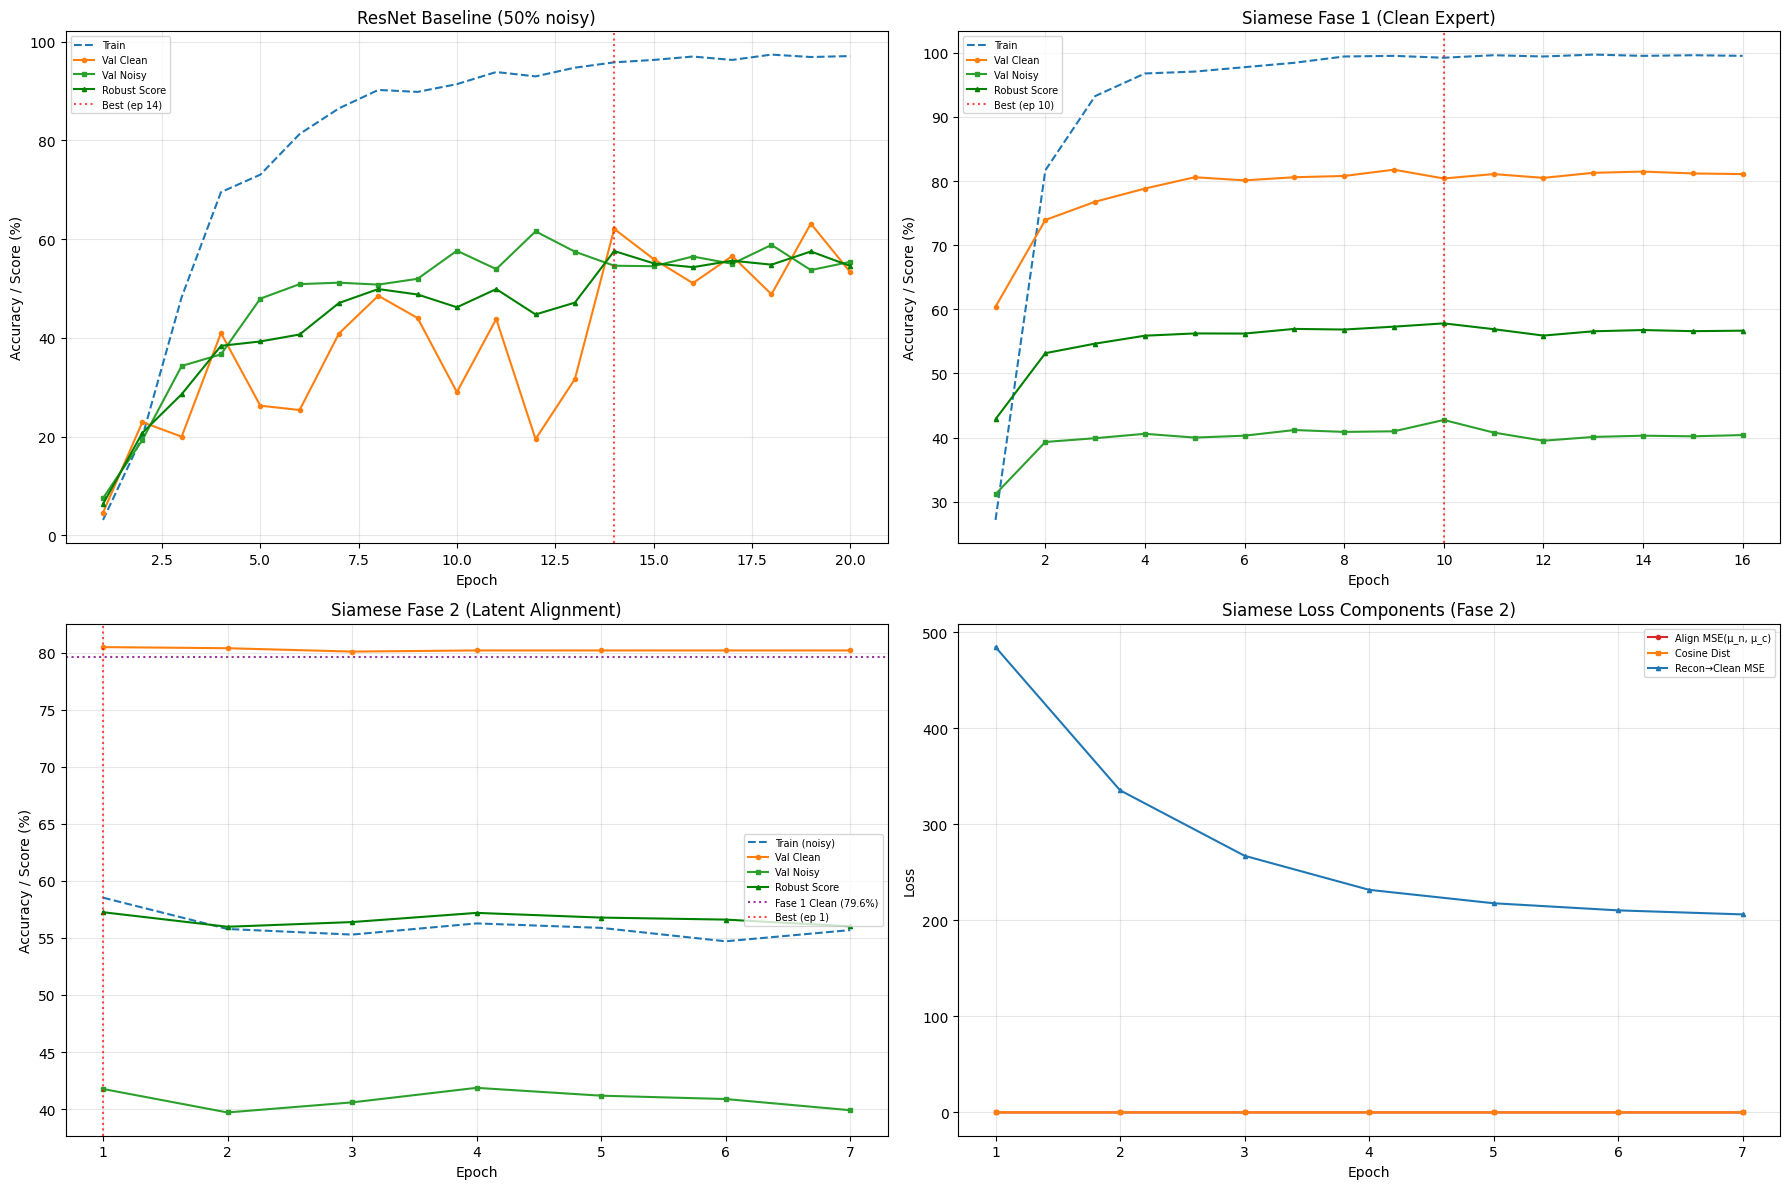

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- ResNet Baseline ---
ax = axes[0, 0]
ep_r = range(1, len(history_resnet['train_acc']) + 1)
ax.plot(ep_r, history_resnet['train_acc'], '--', label='Train')
ax.plot(ep_r, history_resnet['clean_acc'], '-o', markersize=3, label='Val Clean')
ax.plot(ep_r, history_resnet['noisy_acc'], '-s', markersize=3, label='Val Noisy')
ax.plot(ep_r, history_resnet['score'], '-^', markersize=3, label='Robust Score', color='green')
if best_resnet_epoch <= len(ep_r):
    ax.axvline(x=best_resnet_epoch, color='red', linestyle=':', alpha=0.7, label=f'Best (ep {best_resnet_epoch})')
ax.set_title('ResNet Baseline (50% noisy)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy / Score (%)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# --- Siamese Phase 1 ---
ax = axes[0, 1]
ep1 = range(1, len(history_p1['train_acc']) + 1)
ax.plot(ep1, history_p1['train_acc'], '--', label='Train')
ax.plot(ep1, history_p1['clean_acc'], '-o', markersize=3, label='Val Clean')
ax.plot(ep1, history_p1['noisy_acc'], '-s', markersize=3, label='Val Noisy')
ax.plot(ep1, history_p1['score'], '-^', markersize=3, label='Robust Score', color='green')
if best_p1_epoch <= len(ep1):
    ax.axvline(x=best_p1_epoch, color='red', linestyle=':', alpha=0.7, label=f'Best (ep {best_p1_epoch})')
ax.set_title('Siamese Fase 1 (Clean Expert)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy / Score (%)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# --- Siamese Phase 2 ---
ax = axes[1, 0]
ep2 = range(1, len(history_p2['train_acc']) + 1)
ax.plot(ep2, history_p2['train_acc'], '--', label='Train (noisy)')
ax.plot(ep2, history_p2['clean_acc'], '-o', markersize=3, label='Val Clean')
ax.plot(ep2, history_p2['noisy_acc'], '-s', markersize=3, label='Val Noisy')
ax.plot(ep2, history_p2['score'], '-^', markersize=3, label='Robust Score', color='green')
ax.axhline(y=phase1_test_clean, color='purple', linestyle=':', alpha=0.8, label=f'Fase 1 Clean ({phase1_test_clean:.1f}%)')
if best_p2_epoch <= len(ep2):
    ax.axvline(x=best_p2_epoch, color='red', linestyle=':', alpha=0.7, label=f'Best (ep {best_p2_epoch})')
ax.set_title('Siamese Fase 2 (Latent Alignment)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy / Score (%)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# --- Alignment Losses (Phase 2) ---
ax = axes[1, 1]
ax.plot(ep2, history_p2['align_mse'], '-o', markersize=3, label='Align MSE(μ_n, μ_c)', color='tab:red')
ax.plot(ep2, history_p2['cosine_dist'], '-s', markersize=3, label='Cosine Dist', color='tab:orange')
ax.plot(ep2, history_p2['recon_clean'], '-^', markersize=3, label='Recon→Clean MSE', color='tab:blue')
ax.set_title('Siamese Loss Components (Fase 2)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

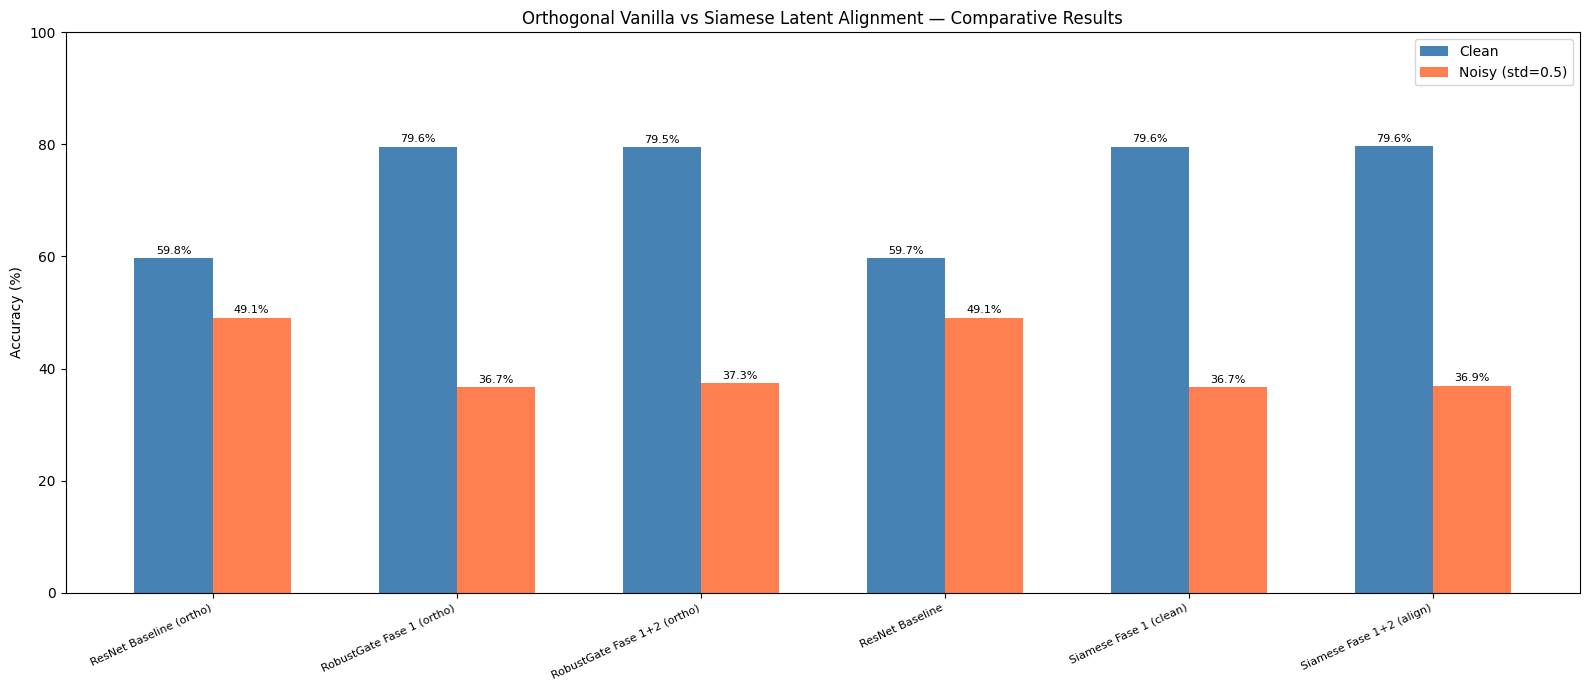

In [13]:
names = list(all_results.keys())
clean_vals = [all_results[n]['clean'] for n in names]
noisy_vals = [all_results[n]['noisy'] for n in names]

x = np.arange(len(names))
w = 0.32

fig, ax = plt.subplots(figsize=(16, 7))
b1 = ax.bar(x - w/2, clean_vals, w, label='Clean', color='steelblue')
b2 = ax.bar(x + w/2, noisy_vals, w, label='Noisy (std=0.5)', color='coral')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Orthogonal Vanilla vs Siamese Latent Alignment — Comparative Results')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=8, rotation=25, ha='right')
ax.legend()
ax.set_ylim(0, 100)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## Guardar modelo y metadatos

In [14]:
os.makedirs('../../out/dememte_siamese_flowers102', exist_ok=True)

save_path = '../../out/dememte_siamese_flowers102/dememte_siamese_alignment.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'metadata': {
        'variant': 'siamese_latent_alignment',
        'approach': 'Bio-inspired contrastive memory (hippocampal invariance)',
        'gating': 'sigmoid(alpha * (tau - batch_norm(recon)))',
        'siamese_loss': 'MSE(mu_noisy, mu_clean) + cosine_dist + recon_to_clean',
        'dataset': 'Flowers102',
        'epochs_phase1': best_p1_epoch,
        'epochs_phase2': best_p2_epoch,
        'noise_std': NOISE_STD,
        'loss_weights': {
            'align_mse': ALIGN_WEIGHT,
            'cosine': COSINE_WEIGHT,
            'vae': VAE_WEIGHT,
            'sparsity': SPARSITY_WEIGHT,
        },
        'phase1_test_clean': phase1_test_clean,
        'phase1_test_noisy': phase1_test_noisy,
        'phase2_test_clean': phase2_test_clean,
        'phase2_test_noisy': phase2_test_noisy,
        'classifier_frozen_in_phase2': True,
        'vs_orthogonal_vanilla': {
            'ortho_phase2_noisy': 37.34,
            'siamese_phase2_noisy': phase2_test_noisy,
            'improvement': phase2_test_noisy - 37.34,
        },
        'regularization': {
            'optimizer': 'AdamW',
            'weight_decay': 1e-4,
            'label_smoothing': 0.05,
            'grad_clip': 1.0,
            'scheduler': 'ReduceLROnPlateau',
            'early_stopping_patience': PATIENCE,
        },
    }
}, save_path)

resnet_path = '../../out/dememte_siamese_flowers102/resnet_noisy_baseline.pth'
torch.save({
    'model_state_dict': resnet.state_dict(),
    'metadata': {
        'model': 'resnet18_noisy_baseline',
        'dataset': 'Flowers102',
        'best_epoch': best_resnet_epoch,
        'noise_std': NOISE_STD,
        'test_clean_acc': resnet_test_clean,
        'test_noisy_acc': resnet_test_noisy,
    }
}, resnet_path)

# Guardar historial completo como JSON
history_path = '../../out/dememte_siamese_flowers102/training_history.json'
with open(history_path, 'w') as f:
    json.dump({
        'resnet': history_resnet,
        'phase1': history_p1,
        'phase2_siamese': history_p2,
    }, f, indent=2)

print(f'Saved model: {save_path}')
print(f'Saved baseline: {resnet_path}')
print(f'Saved history: {history_path}')

Saved model: ../../out/dememte_siamese_flowers102/dememte_siamese_alignment.pth
Saved baseline: ../../out/dememte_siamese_flowers102/resnet_noisy_baseline.pth
Saved history: ../../out/dememte_siamese_flowers102/training_history.json
